# H1 — Biological overlap networks

## Purpose
This notebook turns the per-pair biological similarity scores computed in [`biological_overlap.ipynb`](./biological_overlap.ipynb) into weighted, undirected `networkx` graphs suitable for node2vec embedding.

There are **9 biological "layers"**, each capturing a different facet of target/pathway overlap between two drugs. (See the Glossary below if any of "target," "enzyme/transporter/carrier," "GO," "Pfam," or "pathway" is unfamiliar.)

| Layer | What it measures | In plain English |
|---|---|---|
| `identity_L0` | Direct target overlap: `T(d) = DrugBank targets ∪ ChEMBL mechanism/bioactivity targets` | Do the two drugs act on the same protein(s)? |
| `identity_L1` | `L0 ∪` shared enzymes `∪` shared transporters | `L0`, plus: do the two drugs share the proteins that break them down or move them around the body? |
| `identity_L2` | `L1 ∪` shared carriers | `L1`, plus: do they also share the proteins that ferry them through the bloodstream? |
| `go_mf` | Shared Gene Ontology Molecular Function terms | Do their target proteins do the same *kind* of job at a molecular level? |
| `go_bp` | Shared Gene Ontology Biological Process terms | Are their target proteins part of the same larger biological process? |
| `go_cc` | Shared Gene Ontology Cellular Component terms | Are their target proteins found in the same part of the cell? |
| `pfam` | Shared Pfam protein domains | Do their target proteins share a recognizable structural building block, even if otherwise different? |
| `pathway_native` | Shared native SMPDB pathway membership (Φ_native) | Are both drugs *documented* as involved in the same named biological pathway? |
| `pathway_inferred` | Shared inferred two-hop pathway neighbors, reseeded from `L0` (Φ_infer) | Even without direct documentation, do both drugs sit close to the same pathway based on shared neighboring proteins? |

For each layer we build **two** graphs -- one over the curated *adverse* DDI pairs, one over the sampled *non-interacting* pairs -- so downstream models can compare embeddings learned from each pair population. That gives **18 graphs in total** (9 layers × 2 datasets).

## Pipeline
1. Load the per-pair Jaccard scores for all 9 layers.
2. Pivot each (dataset, layer) pair-list into a dense drug-by-drug similarity matrix.
3. Sparsify each dense matrix into a graph using [`src/network_builder.py`](../../src/network_builder.py) (hybrid top-k + minimum-similarity sparsification).
4. Run the network diagnostics suite (edge-weight sanity, degree distribution, DDI-topology check) on every graph and summarize the results in one table.
5. Save every graph to GraphML under `networks/`.

## Key caveat -- read before trusting the diagnostics
These parquet files only contain the **specific pairs that were sampled** for the adverse/non-interacting datasets, not the full N-choose-2 universe of DrugBank pairs. When we pivot into a dense matrix (Section 2), every unsampled pair is filled with `0.0` -- this conflates "never measured" with "measured and dissimilar". That's an acceptable approximation for this project's two curated pair populations, but it means the diagnostics below describe how well similarity separates *these specific* adverse vs. non-interacting samples, not a fully general drug-drug similarity space.

## Glossary (plain-English definitions)

This notebook uses a lot of specialized vocabulary. Here's what everything means, roughly in the order it first comes up:

- **Graph / node / edge:** A *graph* here is just drugs (the *nodes*, i.e. the dots) connected by lines (the *edges*) whenever two drugs are "similar enough." Each edge also carries a *weight* -- a number saying *how* similar, not just *whether* they're similar.
- **Undirected:** The connection between two drugs goes both ways equally -- there's no "sender" or "receiver," just "these two are related."
- **node2vec:** A machine-learning technique (used later in this project, not in this notebook) that reads a graph and converts each node into a list of numbers (an "embedding") summarizing its neighborhood, which can then be fed into a predictive model. This notebook's whole job is to build graphs that are *good input* for that later step.
- **DrugBank ID:** The unique code (like `DB00001`) that the [DrugBank](https://go.drugbank.com/) database assigns to each drug. We use these instead of drug names because the per-pair files here don't include names.
- **Jaccard similarity:** A simple way to measure overlap between two sets: (things both drugs share) ÷ (all the things either drug has). Example: if Drug A's targets are `{1, 2, 3}` and Drug B's are `{2, 3, 4}`, they share `{2, 3}` (2 items) out of a combined `{1, 2, 3, 4}` (4 items), so Jaccard = 2/4 = 0.5. A value of 0 means no overlap at all; 1 means identical sets.
- **Tversky index ("directional containment"):** Like Jaccard, but not symmetric -- it asks "what fraction of *drug A's* stuff is also in drug B?", which can differ from the reverse direction (e.g. a drug with only 2 targets that are both shared with a drug that has 50 targets scores very differently depending on direction). We don't use this for the graph's edge weight, but it's stored in the data for later, more detailed analysis.
- **Target / enzyme / transporter / carrier:** Types of proteins a drug interacts with in the body. A *target* is what the drug is meant to act on (e.g. a receptor). An *enzyme* breaks the drug down. A *transporter* moves the drug across cell membranes. A *carrier* binds and ferries the drug through the bloodstream.
- **Gene Ontology (GO):** A standard vocabulary biologists use to describe what a protein does. We use three "aspects": **Molecular Function** (the specific job, e.g. "binds calcium"), **Biological Process** (the larger process it's part of, e.g. "blood clotting"), and **Cellular Component** (where in the cell it's found, e.g. "cell membrane").
- **Pfam domain:** A recognizable, reusable building-block segment of a protein's structure. Two proteins can share a Pfam domain (like sharing the same "seatbelt buckle" part) even if the rest of the protein is completely different.
- **SMPDB pathway:** A documented, named biological pathway -- a chain of proteins/reactions the body uses to accomplish something (e.g. a specific metabolic process). Two drugs "sharing a pathway" means both interact with something in that same documented chain.
- **Native vs. inferred pathway membership:** *Native* means a drug is directly documented as part of that pathway. *Inferred* means it isn't directly documented, but it shares enough proteins with drugs that are, that it's probably involved too.
- **Sparsification:** If we connected every drug to every other drug with any nonzero similarity, the resulting graph would be enormous and mostly noise. *Sparsifying* means deliberately keeping only the strongest, most meaningful connections and throwing the rest away.
- **Dense matrix vs. pair list:** A *pair list* (what our parquet files contain) is a table of only the specific drug pairs we happened to sample -- like a list of phone calls that were actually made. A *dense matrix* is a full grid comparing every drug to every other drug -- like a mileage chart between every pair of cities, filled in even for cities that never called each other (we fill those in with 0).
- **k-nearest-neighbors ("top-k"):** For each drug, keep only its `k` most similar other drugs -- like each person keeping only their 15 closest friends instead of everyone they've ever met.
- **Hybrid sparsification:** Our chosen strategy: combine top-k ("each drug keeps its best `k` connections") with a minimum-similarity floor ("but only if the connection is actually meaningful"), so a drug with no good matches isn't forced to keep 15 near-meaningless ones just to hit the quota.
- **Spearman correlation ("rho", ρ):** A score from -1 to 1 measuring whether two things tend to rise and fall together (not necessarily in a straight line). 0 means no relationship; close to +1 or -1 means a strong relationship. We use this to check that edge weight isn't secretly just tracking drug-profile size.
- **"Size leakage":** A pitfall where a similarity score looks meaningful but is actually just reflecting how *much data* a drug has (e.g. a drug with 500 known targets will "share something" with almost anyone), rather than genuine biological relatedness.
- **Isolate (isolated node):** A drug left with zero connections after sparsification -- useless for node2vec, since it has no neighborhood to learn from.
- **Degree:** How many connections (edges) a node has.
- **Percentile (e.g. "5th-percentile degree"):** The value below which a given percentage of the data falls. A "5th-percentile degree of 5" means 95% of drugs have at least 5 connections, and only the bottom 5% have fewer.
- **AUROC (Area Under the ROC Curve):** A score from 0 to 1 measuring how well a single number (here, similarity) can separate two known groups (real adverse drug-drug interaction pairs vs. random unrelated pairs). 0.5 = no better than a coin flip; 1.0 = perfect separation.
- **DDI (Drug-Drug Interaction):** When taking two drugs together causes an effect that wouldn't happen with either drug alone.
- **GraphML:** A standard file format for saving graphs (nodes, edges, weights) so other tools (Gephi, Cytoscape, node2vec libraries, etc.) can load them back in.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from network_builder import build_sparsified_graph, edge_list_to_matrix, NetworkDiagnostics

OUTPUT_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\networks")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load per-pair biological similarity scores

`adverse_biological_overlap_extended.parquet` / `non_interacting_biological_overlap_extended.parquet` each have one row per drug pair with `drug1_id`, `drug2_id`, and three columns per layer:
- `{layer}_jaccard` -- symmetric Jaccard similarity (the value we use as edge weight below)
- `{layer}_tversky_1_in_2` / `{layer}_tversky_2_in_1` -- directional containment (not used for the undirected graph, but useful for later asymmetric analyses)

No drug names are stored in these files (only DrugBank IDs), so the biological graphs below are unlabeled beyond their node IDs.

In [2]:
adverse_bio_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\adverse_biological_overlap_extended.parquet")
non_interacting_bio_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\non_interacting_biological_overlap_extended.parquet")

print(adverse_bio_df.shape, non_interacting_bio_df.shape)
adverse_bio_df.head()

(471895, 38) (161098, 38)


,drug1_id,drug2_id,identity_L0_jaccard,identity_L0_tversky_1_in_2,identity_L0_tversky_2_in_1,identity_L0_shared_ids,identity_L1_jaccard,identity_L1_tversky_1_in_2,identity_L1_tversky_2_in_1,identity_L1_shared_ids,...,pfam_tversky_2_in_1,pfam_shared_ids,pathway_native_jaccard,pathway_native_tversky_1_in_2,pathway_native_tversky_2_in_1,pathway_native_shared_ids,pathway_inferred_jaccard,pathway_inferred_tversky_1_in_2,pathway_inferred_tversky_2_in_1,pathway_inferred_shared_ids
0,DB00006,DB06605,0.0,0.0,0.0,[],0.000000,0.0,0.000,[],...,0.5,"[PF00089, PF00594]",0.0,0.0,0.0,[],0.090023,0.091954,0.810811,"[O00468, O75056, O75469, O75487, P00451, P0048..."
1,DB00006,DB06695,1.0,1.0,1.0,[P00734],0.111111,0.5,0.125,[P00734],...,1.0,"[PF00051, PF00089, PF00594, PF09396]",0.0,0.0,0.0,[],1.000000,1.000000,1.000000,"[A0A075B6P5, A0A075B6S6, A0A0C4DH25, A0A0C4DH7..."
2,DB00006,DB01254,0.0,0.0,0.0,[],0.000000,0.0,0.000,[],...,0.0,[],0.0,0.0,0.0,[],0.216508,0.767816,0.231676,"[A0A075B6P5, A0A075B6S6, A0A0C4DH25, A0A0C4DH7..."
3,DB00006,DB01609,0.0,0.0,0.0,[],0.000000,0.0,0.000,[],...,0.0,[],0.0,0.0,0.0,[],0.000000,0.000000,0.000000,[]
4,DB00006,DB01586,0.0,0.0,0.0,[],0.000000,0.0,0.000,[],...,0.0,[],0.0,0.0,0.0,[],0.034254,0.051341,0.093315,"[O14556, O14842, O43708, O75311, O75469, O9490..."


## 2. Per-drug profile sizes (for the size-leakage diagnostic)

Diagnostic A checks whether edge weight is secretly just a proxy for *how big* a drug's profile is (e.g. a promiscuous drug with 500 known targets will share "something" with almost anyone). That check needs each drug's raw profile size per layer, which lives in `drug_biological_profile_ids.parquet` (built by `biological_overlap.ipynb`, one row per drug with the full id list for every layer) -- **not** in the pair-level files loaded above.

That lookup file is only produced once `biological_overlap.ipynb` has actually been run end to end (it depends on the DrugBank XML dump + SMPDB data, which aren't always available locally). We load it defensively: if it's missing, the size-based checks are skipped for this run and every other diagnostic still executes.

In [3]:
LAYERS = [
    "identity_L0", "identity_L1", "identity_L2",
    "go_mf", "go_bp", "go_cc",
    "pfam", "pathway_native", "pathway_inferred",
]
DATASETS = {"adverse": adverse_bio_df, "non_interacting": non_interacting_bio_df}

PROFILE_LOOKUP_PATH = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\drug_biological_profile_ids.parquet")

PROFILE_SIZES = None

if PROFILE_LOOKUP_PATH.exists():
    _profile_lookup_df = pd.read_parquet(PROFILE_LOOKUP_PATH).set_index("drugbank_id")
    PROFILE_SIZES = {
        layer: _profile_lookup_df[f"{layer}_ids"].apply(len).to_dict()
        for layer in LAYERS
    }
    print("Loaded per-drug profile sizes for the size-leakage diagnostic.")
else:
    print(
        f"WARNING: {PROFILE_LOOKUP_PATH.name} not found -- run biological_overlap.ipynb first if you "
        "want the size-vs-similarity and degree-vs-size diagnostics. Continuing without them."
    )

Loaded per-drug profile sizes for the size-leakage diagnostic.


## 3. Sparsification strategy

The 9 layers have very different densities -- from `biological_overlap.ipynb`'s own diagnostics, `identity_L0` is nonzero for only ~1-6% of pairs while `pathway_inferred` is nonzero for ~64-77%. A single global threshold would either erase the sparse layers or barely prune the dense ones, so we use **`method="hybrid"`** for every layer:
- keep each drug's `K_NEIGHBORS` highest-similarity neighbors (bounds hub degree in the dense layers),
- but require `weight >= MIN_SIMILARITY` (drops the zero/near-zero "neighbors" that sparse layers would otherwise be forced to include just to fill out top-k).

`MIN_SIMILARITY` is set to a tiny epsilon rather than `0.0` so it plays the same role as the original "edge only if weight > 0" rule, while `K_NEIGHBORS` additionally caps how many edges a single highly-connected drug can accumulate. Both constants are tunable -- rerun Section 4 after changing them.

In [4]:
K_NEIGHBORS = 15
MIN_SIMILARITY = 1e-9  # excludes true zero-Jaccard "neighbors"; raise this to prune weak edges further

## 4. Build the dense matrices and sparsified graphs

For every (dataset, layer) combination: pivot the pair list into a dense drug-by-drug matrix with `edge_list_to_matrix`, then sparsify it with `build_sparsified_graph(method="hybrid", ...)`. The dense matrices are kept around (`bio_matrices`) since the diagnostics in Section 5 need the original similarity scores, not just the graph.

In [5]:
bio_matrices = {}
bio_graphs = {}
for label, df in DATASETS.items():
    for layer in LAYERS:
        sim_df = edge_list_to_matrix(df, weight_col=f"{layer}_jaccard")
        G = build_sparsified_graph(sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
        bio_matrices[(label, layer)] = sim_df
        bio_graphs[(label, layer)] = G
        print(f"{label:<16} {layer:<18}: {sim_df.shape[0]:>5} drugs, {G.number_of_edges():>7} edges kept")

adverse          identity_L0       :  1893 drugs,   10283 edges kept
adverse          identity_L1       :  1893 drugs,   17140 edges kept
adverse          identity_L2       :  1893 drugs,   17408 edges kept
adverse          go_mf             :  1893 drugs,   16173 edges kept
adverse          go_bp             :  1893 drugs,   16743 edges kept
adverse          go_cc             :  1893 drugs,   18334 edges kept
adverse          pfam              :  1893 drugs,   14727 edges kept
adverse          pathway_native    :  1893 drugs,    3779 edges kept
adverse          pathway_inferred  :  1893 drugs,   17579 edges kept
non_interacting  identity_L0       :  1893 drugs,    1490 edges kept
non_interacting  identity_L1       :  1893 drugs,   13905 edges kept
non_interacting  identity_L2       :  1893 drugs,   14519 edges kept
non_interacting  go_mf             :  1893 drugs,   13867 edges kept
non_interacting  go_bp             :  1893 drugs,   15196 edges kept
non_interacting  go_cc            

## 5. Diagnostics

*(See the Glossary above for what "Spearman rho," "isolate," "degree," and "AUROC" mean.)*

For every graph we run:
- **Diagnostic A (edge weights):** Spearman rho between edge weight and drug-pair size metrics -- i.e. does a bigger combined profile size predict a bigger similarity score, even when it shouldn't? (pass: rho ≈ 0 -- skipped when `PROFILE_SIZES` is unavailable), plus the isolate/degree checks below.
- **Diagnostic B (degree distribution):** isolate count and 5th-percentile degree (pass: 0 isolates, p5 >= 5 -- i.e. essentially no drug is left disconnected or nearly so), and degree-vs-size slope (pass: flat -- connectivity shouldn't just track profile size).
- **Diagnostic C (DDI topology):** AUROC using edge weight to separate known adverse DDI pairs from random pairs (pass: AUROC > 0.5, meaning the similarity score is actually better than a coin flip at spotting real interacting pairs). This only makes sense for the **adverse** graphs -- the non-interacting sample has no known-positive labels of its own, so Diagnostic C is skipped for it (you'll see `NaN` in the summary table).

Results for all 18 graphs are collected into one summary table, `bio_diagnostics_df`.

In [6]:
ADVERSE_DDI_EDGES = list(zip(adverse_bio_df["drug1_id"], adverse_bio_df["drug2_id"]))

bio_diag_objects = {}
diagnostic_rows = []
for (label, layer), G in bio_graphs.items():
    size_vector = PROFILE_SIZES[layer] if PROFILE_SIZES else {}
    diag = NetworkDiagnostics(
        graph=G,
        size_vector=size_vector,
        ddi_edges=ADVERSE_DDI_EDGES if label == "adverse" else [],
        sim_df=bio_matrices[(label, layer)],
    )
    bio_diag_objects[(label, layer)] = diag
    result = diag.run_all(n_random=5000)
    diagnostic_rows.append({
        "dataset": label,
        "layer": layer,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "isolate_count": result.get("isolate_count"),
        "p5_degree": result.get("p5_degree"),
        "rho_size_diff": result.get("size_rho_size_diff"),
        "degree_vs_size_slope": result.get("degree_vs_size_slope"),
        "auroc_ddi_prediction": result.get("auroc_ddi_prediction"),
    })

bio_diagnostics_df = pd.DataFrame(diagnostic_rows)
bio_diagnostics_df

,dataset,layer,n_nodes,n_edges,isolate_count,p5_degree,rho_size_diff,degree_vs_size_slope,auroc_ddi_prediction
0,adverse,identity_L0,1893,10283,475,0.0,-0.683895,0.238689,0.530473
1,adverse,identity_L1,1893,17140,239,0.0,-0.336870,0.128470,0.754998
2,adverse,identity_L2,1893,17408,228,0.0,-0.312802,0.143059,0.764318
3,adverse,go_mf,1893,16173,284,0.0,-0.512213,0.155464,0.652470
4,adverse,go_bp,1893,16743,277,0.0,-0.486889,0.046606,0.697731
5,adverse,go_cc,1893,18334,231,0.0,-0.520363,0.127672,0.844068
6,adverse,pfam,1893,14727,364,0.0,-0.867504,0.036328,0.592730
7,adverse,pathway_native,1893,3779,1531,0.0,-0.567501,0.046584,0.522786
8,adverse,pathway_inferred,1893,17579,305,0.0,-0.549019,0.005515,0.886027
9,non_interacting,identity_L0,1893,1490,944,0.0,-0.771850,0.070130,NaN


### 5a. Detail plots for one representative layer

Plotting all 18 weight-distribution and degree-vs-size charts would be more noise than signal, so we drill into `pathway_inferred` (the densest layer, and therefore the one most likely to show hub/isolate problems) for both datasets. Change `DETAIL_LAYER` below to inspect a different layer.

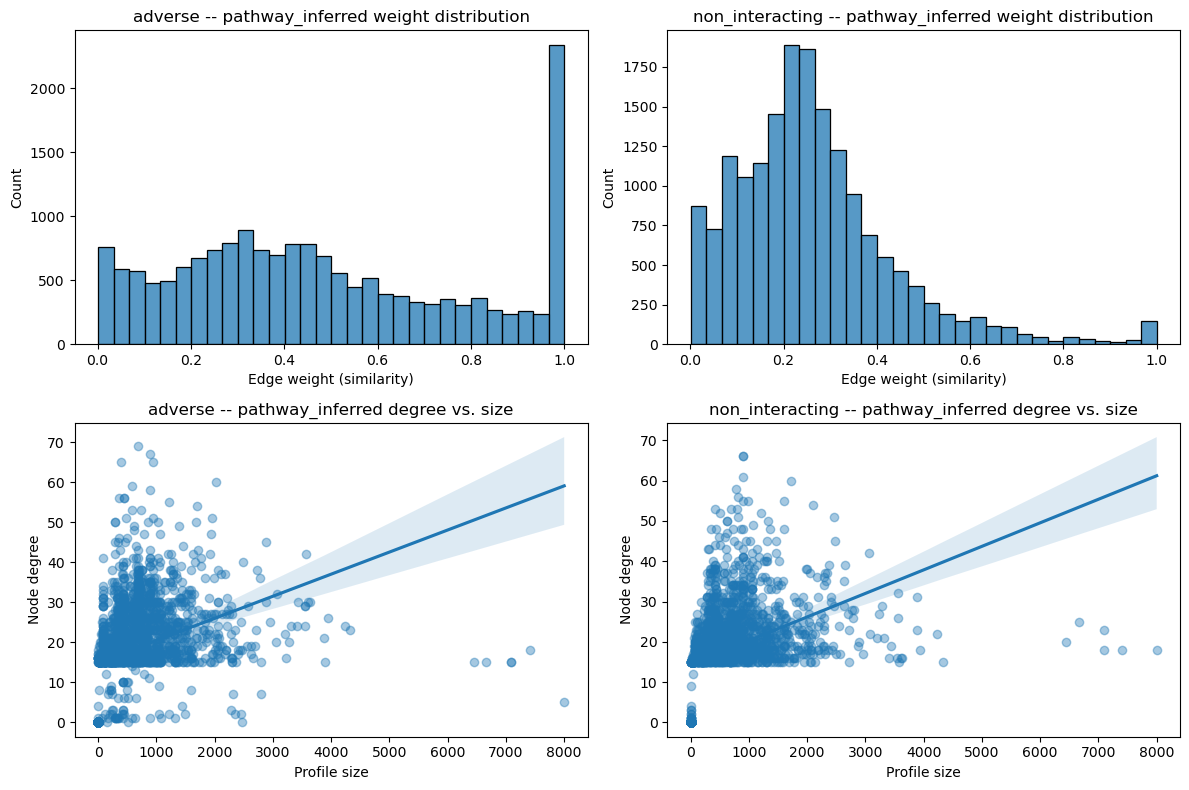

In [7]:
DETAIL_LAYER = "pathway_inferred"

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, label in enumerate(["adverse", "non_interacting"]):
    diag = bio_diag_objects[(label, DETAIL_LAYER)]
    diag.plot_weight_distribution(ax=axes[0, col])
    axes[0, col].set_title(f"{label} -- {DETAIL_LAYER} weight distribution")
    if PROFILE_SIZES:
        diag.degree_vs_size(plot=True, ax=axes[1, col])
        axes[1, col].set_title(f"{label} -- {DETAIL_LAYER} degree vs. size")
    else:
        axes[1, col].axis("off")
        axes[1, col].text(0.5, 0.5, "PROFILE_SIZES unavailable", ha="center", va="center")
plt.tight_layout()
plt.show()

## 6. Save graphs

Each (dataset, layer) graph is written to its own GraphML file under `networks/`, named `{dataset}_{layer}.graphml` (e.g. `adverse_pathway_inferred.graphml`).

In [8]:
for (label, layer), G in bio_graphs.items():
    nx.write_graphml(G, OUTPUT_DIR / f"{label}_{layer}.graphml")

print(f"Saved {len(bio_graphs)} graphs to {OUTPUT_DIR}")

Saved 18 graphs to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\networks


## 7. Build the combined graphs (for node2vec)

`node2vec_embedding.ipynb` needs a **single, label-agnostic** graph per layer to train its canonical embedding on -- using the two per-population graphs above directly would mean two separately-trained node2vec models per layer with unaligned, arbitrary vector spaces (see `node2vec_embedding.ipynb` for why that's invalid for a downstream classifier). Instead, for each of the 9 layers we build one graph from the union of both pair populations, using the same sparsification settings (`K_NEIGHBORS`, `MIN_SIMILARITY`) as Section 4, so all 9 combined graphs are saved alongside the 18 per-population graphs and `node2vec_embedding.ipynb` can just load them.

In [9]:
combined_bio_df = pd.concat([adverse_bio_df, non_interacting_bio_df], ignore_index=True)

combined_graphs = {}
for layer in LAYERS:
    sim_df = edge_list_to_matrix(combined_bio_df, weight_col=f"{layer}_jaccard")
    G_combined = build_sparsified_graph(sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
    combined_graphs[layer] = G_combined

    n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
    nx.write_graphml(G_combined, OUTPUT_DIR / f"combined_{layer}.graphml")
    print(f"combined {layer:<18}: {G_combined.number_of_nodes():>5} nodes, {G_combined.number_of_edges():>7} edges, "
          f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

print(f"\nSaved {len(combined_graphs)} combined graphs to {OUTPUT_DIR}")

combined identity_L0       :  1893 nodes,   10998 edges, 373 isolate(s), density=0.00614
combined identity_L1       :  1893 nodes,   17836 edges, 170 isolate(s), density=0.00996
combined identity_L2       :  1893 nodes,   18054 edges, 160 isolate(s), density=0.01008
combined go_mf             :  1893 nodes,   17225 edges, 234 isolate(s), density=0.00962
combined go_bp             :  1893 nodes,   17623 edges, 243 isolate(s), density=0.00984
combined go_cc             :  1893 nodes,   18750 edges, 223 isolate(s), density=0.01047
combined pfam              :  1893 nodes,   15855 edges, 282 isolate(s), density=0.00885
combined pathway_native    :  1893 nodes,    4055 edges, 1526 isolate(s), density=0.00226
combined pathway_inferred  :  1893 nodes,   17612 edges, 298 isolate(s), density=0.00983

Saved 9 combined graphs to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\networks


## Summary & limitations

**How to read `bio_diagnostics_df`:**
- `isolate_count` should be 0 and `n_edges` should scale roughly with `n_nodes * K_NEIGHBORS / 2` -- if a layer has far fewer edges than that, `MIN_SIMILARITY` is pruning almost everything for that layer (expected for the sparser identity/GO layers).
- `rho_size_diff` / `degree_vs_size_slope` near 0 mean the layer's similarity isn't just an artifact of promiscuous drugs; a strong positive slope flags a layer where large-profile drugs dominate connectivity.
- `auroc_ddi_prediction` (adverse rows only) above 0.5 means this layer's similarity actually helps separate known adverse DDI pairs from random pairs -- values near 0.5 suggest that layer alone isn't informative for DDI prediction (it may still be useful combined with the ATC/structural graphs).

**Known limitations:**
1. The dense matrices are built only from the sampled adverse/non-interacting pairs (see the caveat at the top of this notebook) -- not the full drug universe.
2. `PROFILE_SIZES` (and therefore the size-leakage diagnostics) are only available once `biological_overlap.ipynb` has produced `drug_biological_profile_ids.parquet`.
3. `K_NEIGHBORS` / `MIN_SIMILARITY` are shared across all 9 layers for simplicity; a layer-specific grid search (see `run_diagnostic_sweep` in `src/network_builder.py`) may find better per-layer settings.
4. The 9 combined graphs (Section 7) aren't run through the same diagnostics suite as the 18 per-population graphs -- they're built purely as node2vec training input, not as objects to be evaluated on their own.

## Diagnostics review -- problems & conclusions (from the executed run)

This is a review of the actual `bio_diagnostics_df` output produced by this notebook, called out separately from the generic "how to read this table" guidance above.

### Problems

1. **Every one of the 18 graphs fails the degree-distribution pass bar.** `p5_degree` is `0.0` in every row, and isolate counts range from ~12% up to 81% of all nodes:
   | Layer | Adverse isolates | Non-interacting isolates |
   |---|---|---|
   | `pathway_native` | 1,532 / 1,894 (**81%**) | 1,543 / 1,901 (**81%**) |
   | `identity_L0` | 476 / 1,894 (25%) | 948 / 1,901 (**50%**) |
   | all other layers | 230-365 (12-19%) | 235-465 (12-24%) |

   `pathway_native` and `identity_L0` are effectively unusable for node2vec as currently configured -- most drugs have zero neighbors. This isn't a code bug: `biological_overlap.ipynb`'s own stats already flagged these as the sparsest layers (nonzero for only ~1-6% of pairs), so the hybrid sparsifier simply can't manufacture an edge where the true Jaccard score is 0 against every candidate.

2. **Diagnostic A (size leakage) fails everywhere, and badly.** `rho_size_diff` is large and negative across all 18 rows (range: -0.18 to **-0.90** for `pfam`) -- edge weight is heavily predicted by how similarly *sized* the two drugs' profiles are, much more so than what we saw for the ATC or structural-similarity graphs. `degree_vs_size_slope` is also consistently positive (up to +0.26): bigger-profile drugs systematically pick up more connections, not just higher-weight ones.

### Conclusions

3. **Diagnostic C (DDI topology) shows real, strongly differentiated signal across layers** -- this is the most actionable finding. AUROC (adverse vs. random pairs) by layer:
   | Layer | AUROC | Read |
   |---|---|---|
   | `pathway_inferred` | **0.887** | Strongest single-layer DDI signal |
   | `go_cc` | **0.845** | Very strong |
   | `identity_L2` | 0.764 | Strong |
   | `identity_L1` | 0.755 | Strong |
   | `go_bp` | 0.698 | Moderate |
   | `go_mf` | 0.653 | Moderate |
   | `pfam` | 0.593 | Weak |
   | `pathway_native` | 0.523 | ~coin flip |
   | `identity_L0` | 0.531 | ~coin flip |

   The broader, denser layers (`pathway_inferred`, `go_cc`, `identity_L1`/`identity_L2`) carry real predictive power on their own. The strictest/sparsest layers (`identity_L0`, `pathway_native`) don't -- consistent with their isolate problem above: there simply isn't enough coverage for them to discriminate.

4. **Interesting asymmetry, not necessarily a problem:** `identity_L0` produced 10,246 edges for the adverse graph but only 1,495 for non-interacting -- a ~7x gap using identical `K_NEIGHBORS`/`MIN_SIMILARITY`. That's a good sign the negative-sampling process really did avoid target-sharing pairs, even though it doesn't show up strongly in the AUROC test (which compares against *uniformly random* pairs, not this curated negative sample specifically).

### Recommendations

1. **Drop or re-tune `pathway_native` and `identity_L0`** for node2vec -- at minimum they need a different sparsification (e.g. a much smaller `k`, or no sparsification at all given how sparse they already are) rather than the shared `K_NEIGHBORS=15` / `MIN_SIMILARITY=1e-9` settings.
2. **Prioritize `pathway_inferred`, `go_cc`, `identity_L1`/`identity_L2`** as the layers most worth feeding into node2vec -- they have both reasonable connectivity and real DDI-discriminative power.
3. Since every layer fails Diagnostic A/B under the current shared settings, this is a strong candidate for `run_diagnostic_sweep` (a per-layer grid search over `K_NEIGHBORS`/`MIN_SIMILARITY`/method) rather than one shared configuration across all 9 layers.